[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]
Eigenvalues: [2.93808505 0.9201649  0.14774182 0.02085386]
Eigenvectors:
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


<ipython-input-3-541da9935a4c>:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


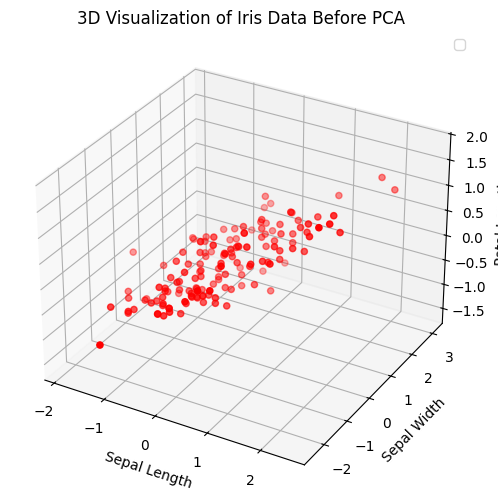

Singular Values: [20.92306556 11.7091661   4.69185798  1.76273239]
Explained Variance by PC1: 0.73
Explained Variance by PC2: 0.23


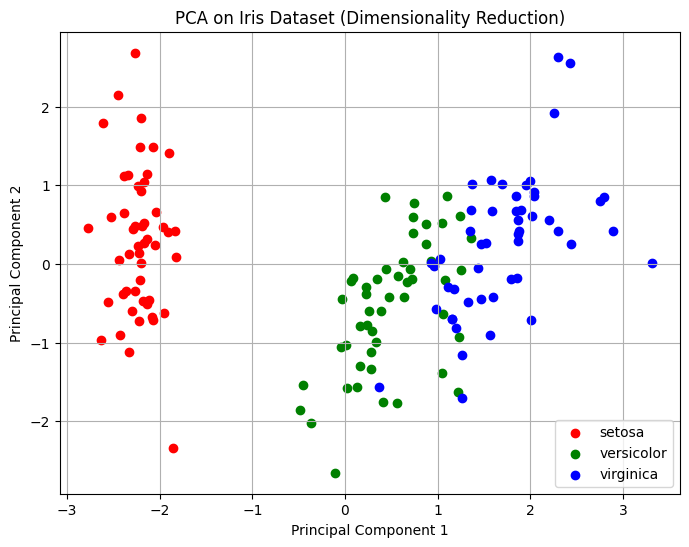

<ipython-input-3-541da9935a4c>:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


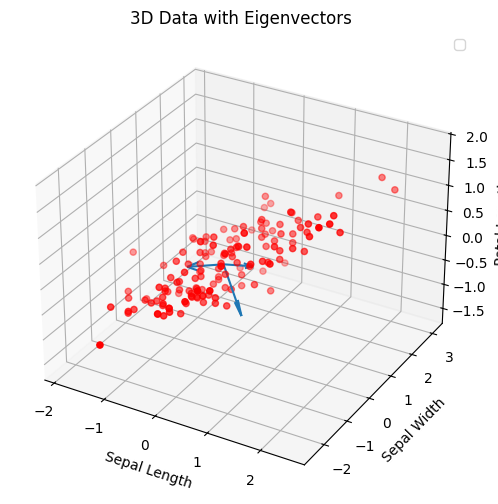

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
iris = datasets.load_iris()
X = iris.data
y = iris.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cov_matrix = np.cov(X_scaled.T)
print(cov_matrix)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue']
labels = iris.target_names
for i in range(len(colors)):
  ax.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1], X_scaled[y == i, 2], color='red')
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Visualization of Iris Data Before PCA')
plt.legend()
plt.show()
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
print("Singular Values:", S)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance by PC1: {explained_variance[0]:.2f}")
print(f"Explained Variance by PC2: {explained_variance[1]:.2f}")
plt.figure(figsize=(8, 6))
for i in range(len(colors)):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=colors[i], label=labels[i])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset (Dimensionality Reduction)')
plt.legend()
plt.grid()
plt.show()
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for i in range(len(colors)):
  ax.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1], X_scaled[y == i, 2], color='red')
for i in range(3):
  ax.quiver(0, 0, 0, eigenvectors[i, 0], eigenvectors[i, 1], eigenvectors[i, 2])
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Data with Eigenvectors')
plt.legend()
plt.show()